<a href="https://colab.research.google.com/github/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/blob/main/Project%201/%5BProject_1%5D_Phase_3_Data_Audit_%26_Forensics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [ ]:
df = pd.read_csv('Mroz.csv')
df = df.drop(columns=['Unnamed: 0'])
df.head()
df.info()
df.describe()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 753 entries, 0 to 752
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   work        753 non-null    object 
 1   hoursw      753 non-null    int64  
 2   child6      753 non-null    int64  
 3   child618    753 non-null    int64  
 4   agew        753 non-null    int64  
 5   educw       753 non-null    int64  
 6   hearnw      753 non-null    float64
 7   wagew       753 non-null    float64
 8   hoursh      753 non-null    int64  
 9   ageh        753 non-null    int64  
 10  educh       753 non-null    int64  
 11  wageh       753 non-null    float64
 12  income      753 non-null    int64  
 13  educwm      753 non-null    int64  
 14  educwf      753 non-null    int64  
 15  unemprate   753 non-null    float64
 16  city        753 non-null    object 
 17  experience  753 non-null    int64  
dtypes: float64(4), int64(12), object(2)
memory usage: 106.0+ KB


,work,hoursw,child6,child618,agew,educw,hearnw,wagew,hoursh,ageh,educh,wageh,income,educwm,educwf,unemprate,city,experience
0,yes,1610,1,0,32,12,3.3540,2.65,2708,34,12,4.0288,16310,12,7,5.0,no,14
1,yes,1656,0,2,30,12,1.3889,2.65,2310,30,9,8.4416,21800,7,7,11.0,yes,5
2,yes,1980,1,3,35,12,4.5455,4.04,3072,40,12,3.5807,21040,12,7,5.0,no,15
3,yes,456,0,3,34,12,1.0965,3.25,1920,53,10,3.5417,7300,7,7,5.0,no,6
4,yes,1568,1,2,31,14,4.5918,3.60,2000,32,12,10.0000,27300,12,14,9.5,yes,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
748,no,0,0,2,40,13,0.0000,0.00,3020,43,16,9.2715,28200,10,10,9.5,yes,5
749,no,0,2,3,31,12,0.0000,0.00,2056,33,12,4.8638,10000,12,12,7.5,no,14
750,no,0,0,0,43,12,0.0000,0.00,2383,43,12,1.0898,9952,10,3,7.5,no,4
751,no,0,0,0,60,12,0.0000,0.00,1705,55,8,12.4400,24984,12,12,14.0,yes,15


The dataset contains 753 observations and 19 variables.

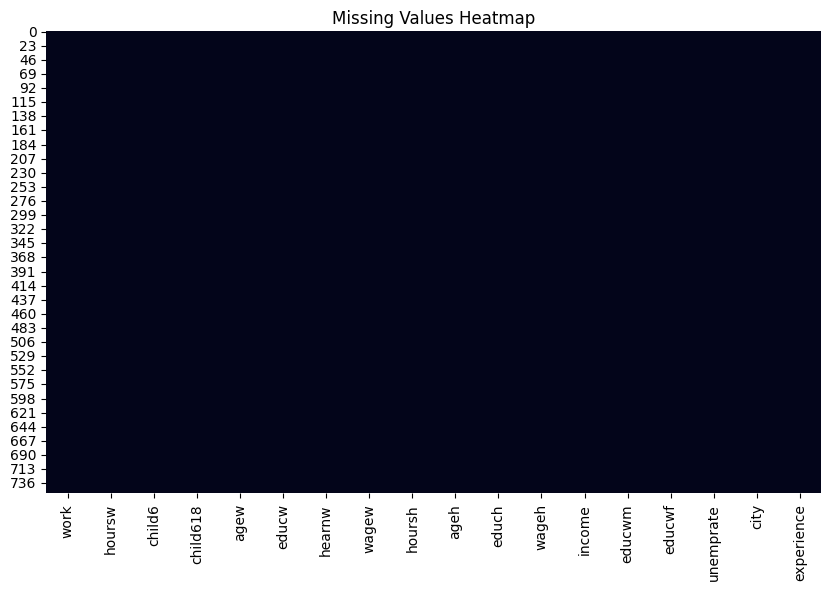

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

The heatmap shows that the dataset contains no conventional missing values.

<function matplotlib.pyplot.show(close=None, block=None)>

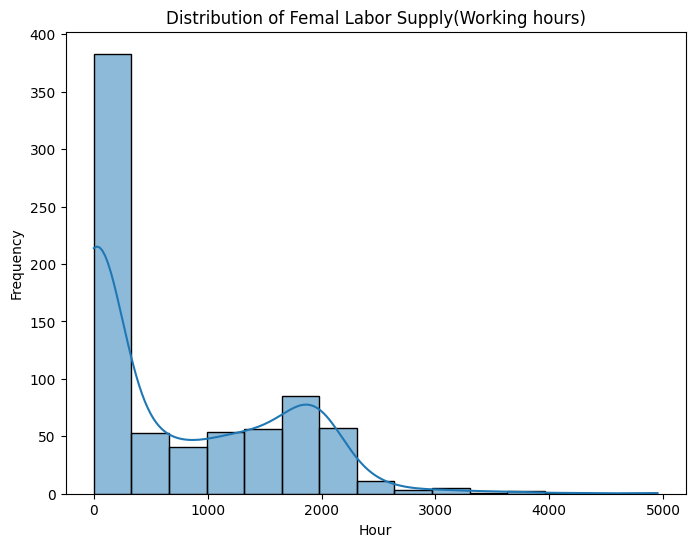

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['hoursw'],kde=True)
plt.title('Distribution of Femal Labor Supply(Working hours)')
plt.xlabel('Hour')
plt.ylabel('Frequency')
plt.show

The graph shows mostr females are concentrated at lower levels of working hours, while a few numbers of females supply a larger number of hours.

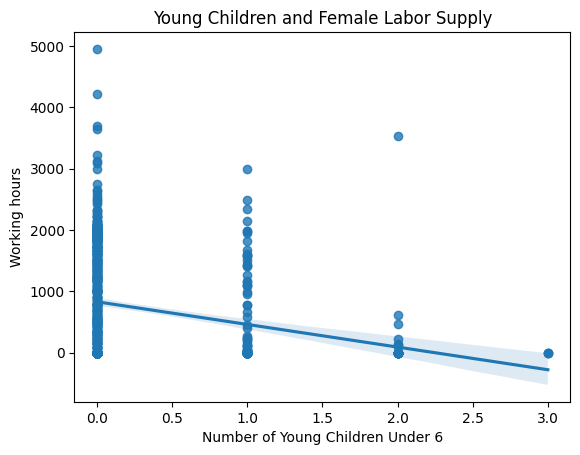

In [ ]:
sns.regplot(x='child6',y='hoursw',data=df)
plt.title("Young Children and Female Labor Supply")
plt.xlabel("Number of Young Children Under 6")
plt.ylabel("Working hours")
plt.show()

The scatter plot shows the relationship between the number of young children and the supply of female labor. The regression line indicates that the number of children under six years old is negatively correlated with working hours. This visual evidence is consistent with the hypothesis that "childcare responsibilities reduce the supply of female labor."

In [ ]:
Q1 = df['hoursw'].quantile(0.25)
Q3 = df['hoursw'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['hoursw'] < lower_bound) | (df['hoursw'] > upper_bound)]
print("Numbers of outliers:",len(outliers))
outliers

Numbers of outliers: 2


,work,hoursw,child6,child618,agew,educw,hearnw,wagew,hoursh,ageh,educh,wageh,income,educwm,educwf,unemprate,city,experience
36,yes,4210,0,0,46,12,2.3753,4.63,1040,49,16,6.9231,20320,3,3,11.0,yes,17
125,yes,4950,0,2,35,12,0.1616,2.75,2504,37,12,6.9888,18700,10,10,7.5,no,17


Outlier detection revealed that only a few extreme observations were present. This also indicates that the dataset appears to be structurally neat, with no regular missing values detected, making it suitable for econometric analysis. Exploratory analysis showed a negative correlation between the number of young children and female labor supply.

In [ ]:
# Manual Implementation of OLS with Heteroskedasticity-Robust Errors
import statsmodels.formula.api as smf

# Define the formula string: Y ~ D + X1 + X2
# Note: We use np.log() directly in the formula for Log-Level specification
formula_1 = 'hoursw ~ child6 + agew + educw + experience'

# Fit the model
model_1 = smf.ols(formula=formula_1, data=df).fit(cov_type='HC1')

# Print the "Regression Anatomy"
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 hoursw   R-squared:                       0.257
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     74.73
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           2.66e-53
Time:                        02:49:50   Log-Likelihood:                -6053.9
No. Observations:                 753   AIC:                         1.212e+04
Df Residuals:                     748   BIC:                         1.214e+04
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1335.3060    247.782      5.389      0.0

The coefficient for the “child6” variable is -447.85, and it is statistically significant at the 1% level. Holding age, education level, and work experience constant (i.e., “all other factors held constant”), each additional child under the age of six is associated with a reduction of approximately 448 hours in annual working hours.
This result indicates a strong negative correlation between young children and female labor supply. This finding is consistent with economic theory, as the responsibility of caring for children reduces the time women have available for labor market activities.
Among the control variables, educational attainment (educw) has a significant positive effect, indicating that women with higher levels of education tend to work longer hours. Experience also shows a significant positive correlation with labor supply. In contrast, age has a negative effect, meaning that older women tend to work fewer hours, even when other factors are held constant.

In [ ]:
# Interaction Term Syntax (:)
# This model includes: education, female, AND (education * female)
formula_interact = 'hoursw ~ child6 * agew + educw + experience'

model_interact = smf.ols(formula=formula_interact, data=df).fit(cov_type='HC1')
print(model_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                 hoursw   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     61.65
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           8.04e-54
Time:                        02:50:52   Log-Likelihood:                -6053.2
No. Observations:                 753   AIC:                         1.212e+04
Df Residuals:                     747   BIC:                         1.215e+04
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    1374.2653    249.447      5.509      

Heterogeneity Analysis

The interaction term between the variables “child6” and “educw” is intended to examine whether the impact of young children on female labor supply varies across different levels of education.
Holding other variables constant (i.e., “ceteris paribus”), the coefficient of the interaction term indicates whether the negative impact of raising young children is stronger or weaker for women with higher levels of education. If the coefficient of the interaction term is positive, this indicates that higher educational attainment mitigates the negative impact of child-rearing on labor supply; in other words, highly educated women are better able to maintain their working hours even when they have young children. If the coefficient is negative, it suggests that this negative impact is more severe for highly educated women.
This distinction is economically significant because education may influence access to childcare resources, work flexibility, or the opportunity cost of time. Thus, this interaction model allows us to examine whether the impact of children is uniform across individuals or varies systematically with educational attainment.